## Dependencies

In [28]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm
import xgboost as xgb
import pandas as pd
import numpy as np
import joblib
import shap
import os

## Classes top features SHAP scores plot

In [11]:
# Function to generate SHAP scores plots
def tree_explainer(model: xgb.core.Booster, 
                    X_test: pd.DataFrame, 
                    target_encoder: LabelEncoder, 
                    class_input: int = 0):
    # Get target class name in string format
    class_names = list(target_encoder.classes_)
    class_name = class_names[class_input]
    # initialise the explainer
    explainer = shap.TreeExplainer(model)
    # Calculate SHAP values
    shap_values = explainer.shap_values(X_test)
    # Formatting
    if isinstance(shap_values, list):
        current_class_shap = np.array(shap_values[class_input])
    elif shap_values.ndim == 3:
        current_class_shap = shap_values[:, :, class_input]
    else:
        current_class_shap = np.array(shap_values)
    # Further formatting
    if current_class_shap.ndim > 2:
        current_class_shap = np.squeeze(current_class_shap)
    # Figure adjustments
    plt.figure(figsize=(10, 8))

    shap.summary_plot(
        current_class_shap,
        X_test,
        plot_type='dot',
        max_display=10,
        show=False
    )

    plt.title(f'feature impact for Class: {class_name}',
            fontsize=16, fontweight='bold', pad=25)
    
    plt.xlabel('SHAP value (impact on model output)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [23]:
# Inference simulation
class XGBInferenceWrapper:
    def __init__(self, model, le_dict, target_encoder):
        self.model = model
        self.le_dict = le_dict 
        self.target_encoder = target_encoder
        self.feature_names = [
            'donorAge', 'reactionSeverity', 'donorCurrentDonationReaction', 
            'timePressureBarGoingToYellowInSeconds', 'instancesMachineWasStoppedByOperator', 
            'instancesMachineStopped', 'lowerPlateletsCount', 'donationElapsedTime', 
            'donorSex', 'needleAdjusted', 'donorHasLowDrawHistory', 
            'donorHasHighReturnHistory', 'donorEBVRiskBracket', 'prev_variance', 
            'prev_variance_1', 'machineRedSquaresVarianceInCicles', 'donationTime', 
            'donorHasACReactionHistory', 'prevACReaction', 'yield', 'operator', 
            'veinUsed', 'highReturnInstances', 'totalDonations'
        ]

    def predict(self, params_dict):
        # Convert to DataFrame and lock the column order
        df = pd.DataFrame([params_dict])
        # Ensure only training features are present and in the right order
        df = df[self.feature_names].copy()
        # Encode categorical columns
        for col, encoder in self.le_dict.items():
            if col in df.columns:
                # Force to string to match '.astype(str)' used in training
                val_as_str = str(df.iloc[0][col]) 
                try:
                    df[col] = encoder.transform([val_as_str])[0]
                except ValueError:
                    # Fallback for unseen labels: use the first known class
                    df[col] = 0 
        # Final Type Cast
        df = df.astype('float32')
        # XGBoost Prediction
        dmat = xgb.DMatrix(df, feature_names=self.feature_names)
        probs = self.model.predict(dmat)
        # Handle Softprob Output
        class_index = np.argmax(probs, axis=1)
        return self.target_encoder.inverse_transform(class_index)

# Initialise the inference engine
engine = joblib.load('inference_pipeline_mk3.pkl')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# Get model features
features = engine.model.feature_names
# Read saved data
data = pd.read_csv('synthetic_dataset.csv')
# Generate features and labels trains
X = data[features].copy()
y = data['label'].copy()
# Encode categorical features
for col, enc in engine.le_dict.items():
    if col in X.columns:
        if col == 'reactionSeverity':
            pass
        else: X[col] = enc.transform(X[col])
# Encore target labels
y_encoded = engine.target_encoder.fit_transform(y)
# Downsample the dataset for easier processing
_, X_sample, _, y_sample = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

X_sample.head()

,donorAge,reactionSeverity,donorCurrentDonationReaction,timePressureBarGoingToYellowInSeconds,instancesMachineWasStoppedByOperator,instancesMachineStopped,lowerPlateletsCount,donationElapsedTime,donorSex,needleAdjusted,...,prev_variance_1,machineRedSquaresVarianceInCicles,donationTime,donorHasACReactionHistory,prevACReaction,yield,operator,veinUsed,highReturnInstances,totalDonations
685916,62,0,2,0,2,0,208,36,1,2,...,1,1,49,0,1,1,1,2,0,26
1171003,19,0,0,10,0,0,271,16,1,2,...,1,1,86,0,0,2,0,2,2,1
384775,40,0,0,0,0,0,237,7,1,0,...,0,2,78,0,0,1,0,2,0,17
2173663,52,0,0,0,0,0,178,12,1,0,...,9,11,31,0,0,0,0,0,0,0
86612,46,0,0,0,0,0,214,22,0,1,...,0,1,33,1,0,0,0,0,2,3


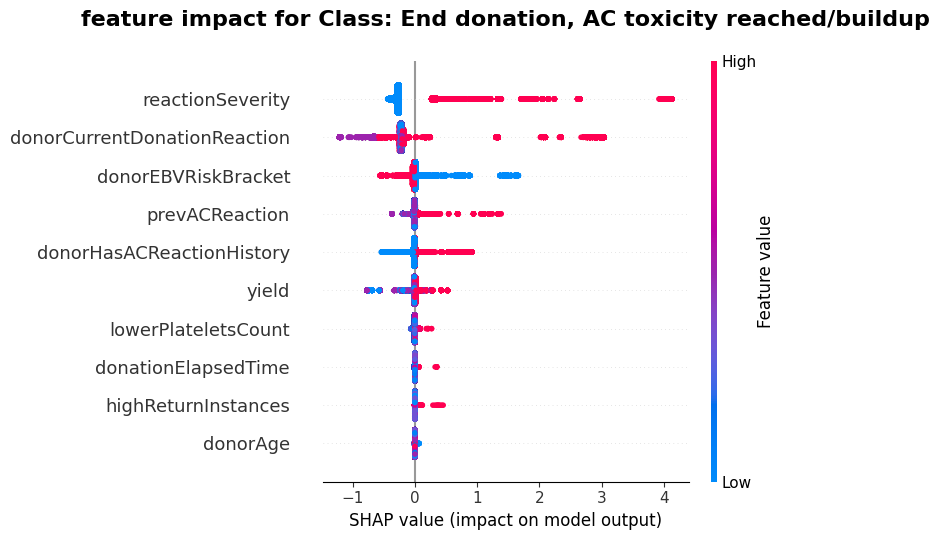

In [12]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 0)

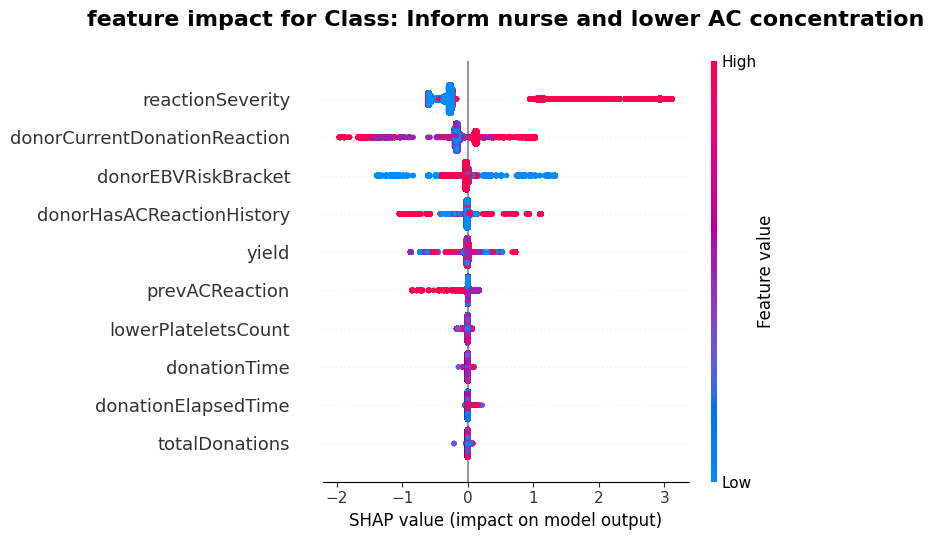

In [13]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 1)

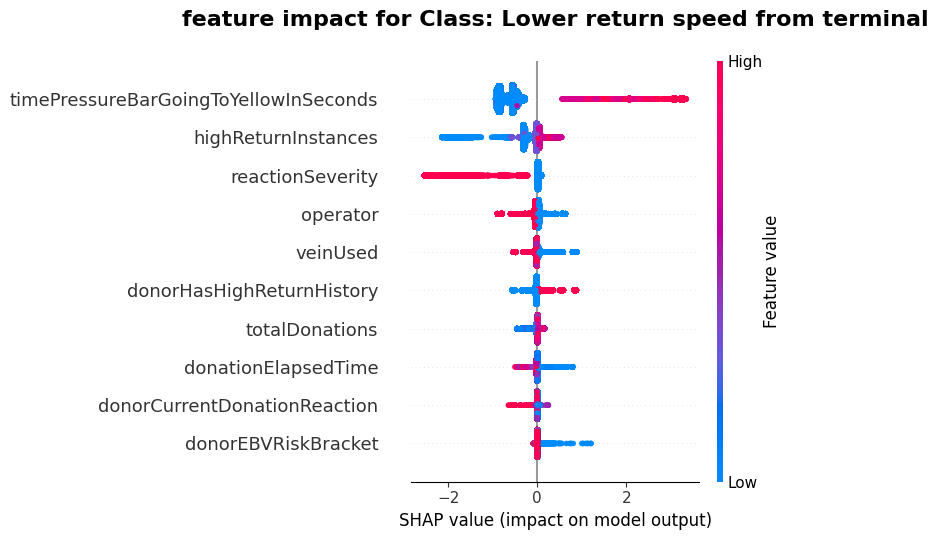

In [14]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 2)

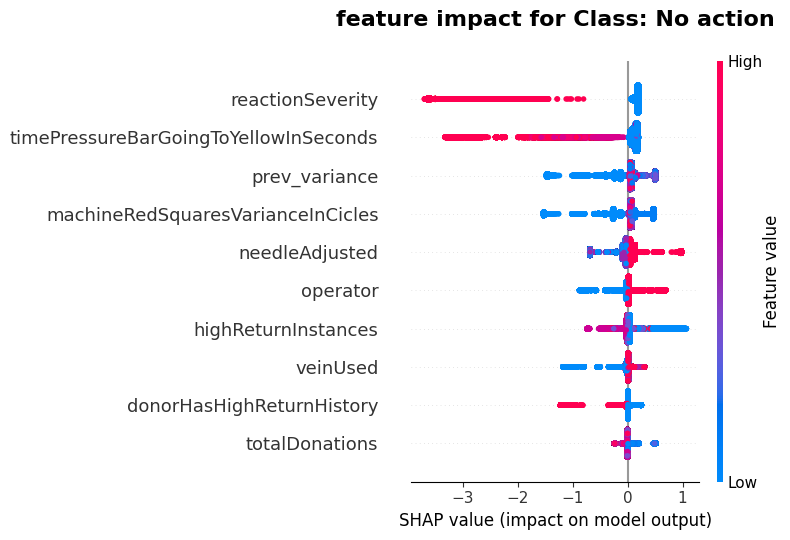

In [15]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 3)

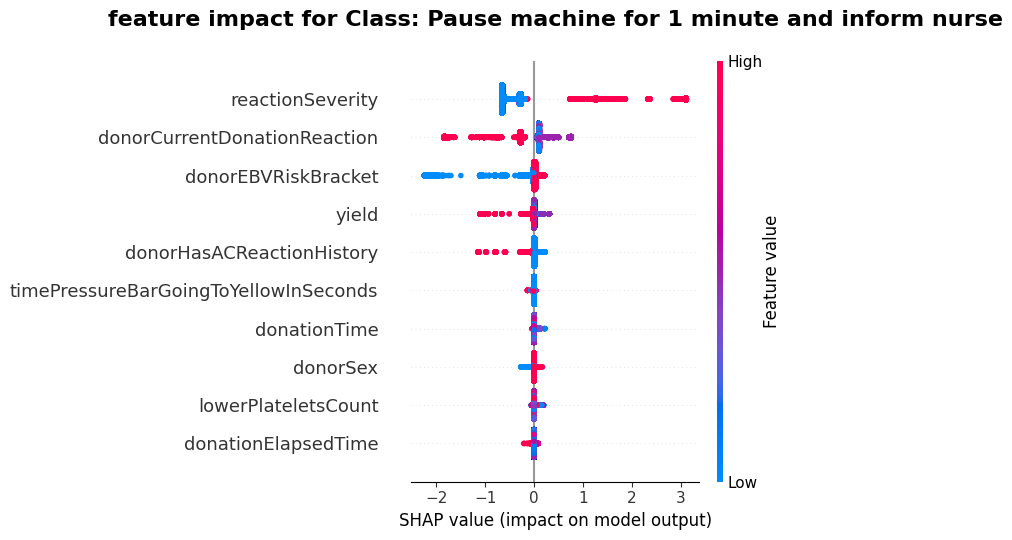

In [16]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 4)

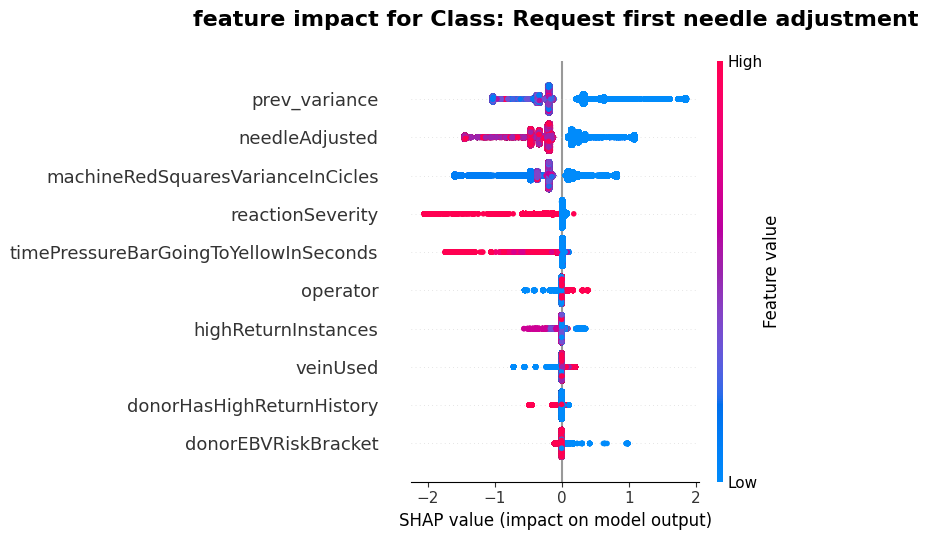

In [17]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 5)

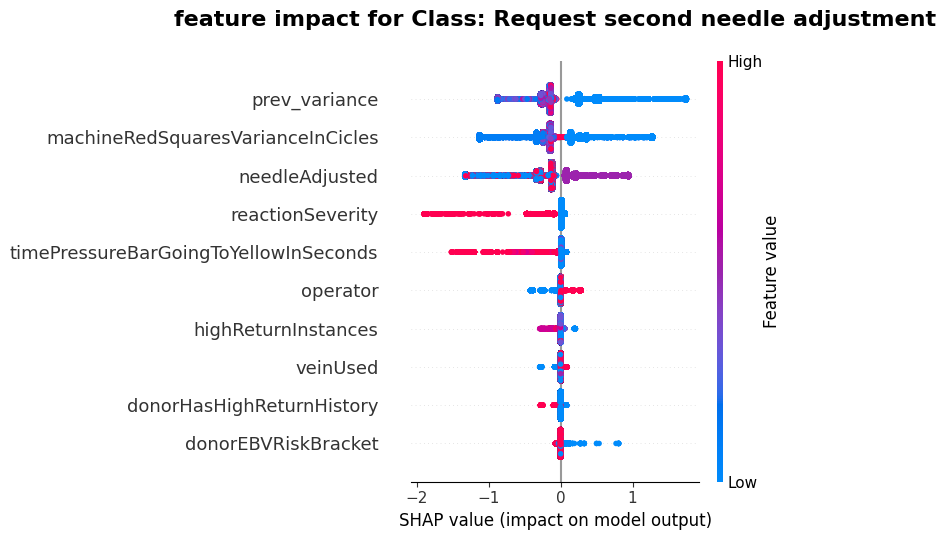

In [18]:
tree_explainer(engine.model, X_sample, engine.target_encoder, 6)

## Top features thresholds

In [799]:
# Data preprocessing
def prepare_pdp_data(df: pd.DataFrame):
    # Drop metadata and targets
    cols_to_drop = ['donorID', 'label', 'predLabel']
    X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    # Final cast to float (removes all 'object' types)
    return X.astype('float32')


# Wrapper required to run PartialDependenceDisplay
class BoosterPDPWrapper:
    _estimator_type = "classifier"
    def __init__(self, booster, feature_names, target_classes):
        self.booster = booster
        self.feature_names = feature_names
        self.classes_ = np.array(target_classes)


    def fit(self, X, y=None): return self


    def predict_proba(self, X):
        # Scikit-learn often passes numpy arrays here.
        # We RE-ATTACH feature names so the Booster doesn't get confused.
        dmat = xgb.DMatrix(X, feature_names=self.feature_names)
        return self.booster.predict(dmat)


# Define classes
clss = list(engine.target_encoder.classes_)

# Prepare the data (Subsample for speed)
X_processed = prepare_pdp_data(X_sample.sample(min(500000, len(X_sample))))
X_pdp = X_processed.sample(min(500000, len(X_processed))) 

# Instantiate the wrapper
pdp_model = BoosterPDPWrapper(
    booster=engine.model,
    feature_names=X_processed.columns.tolist(),
    target_classes=engine.target_encoder.classes_
)


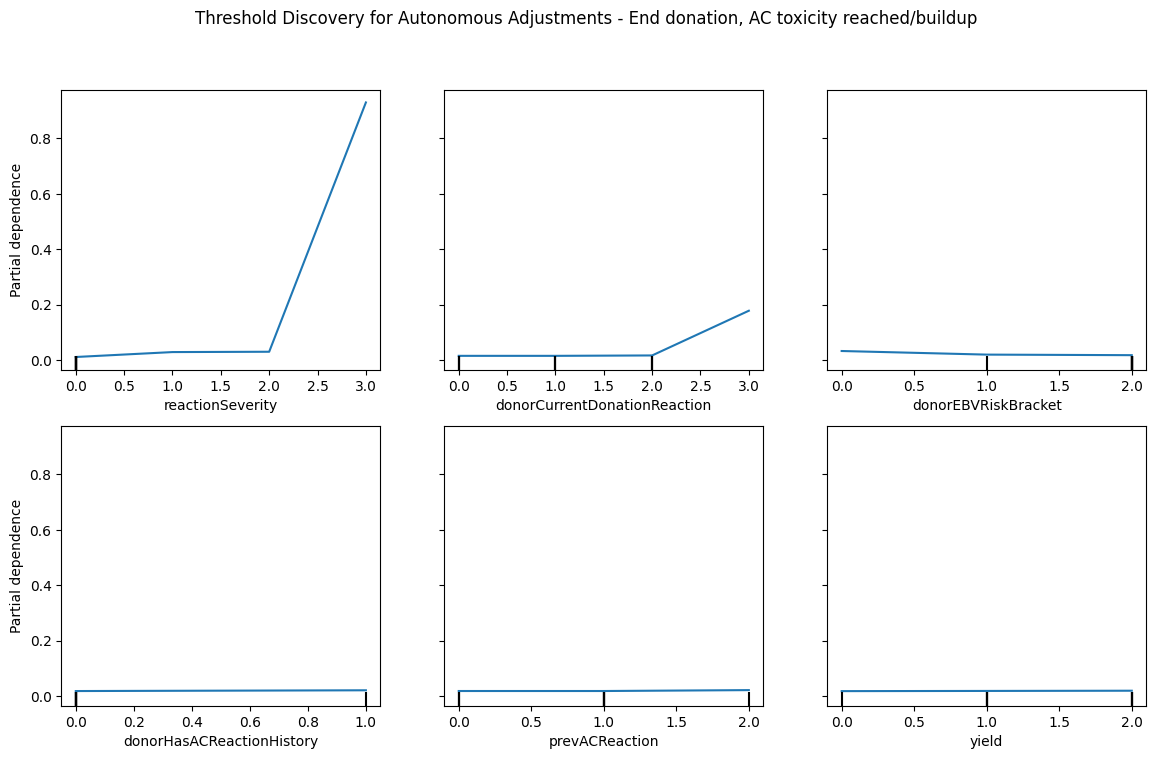

In [816]:
# End donation, AC toxicity reached/buildup
features_to_plot = [
    'reactionSeverity', 'donorCurrentDonationReaction', 'donorEBVRiskBracket',
    'donorHasACReactionHistory', 'prevACReaction', 'yield',
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[0], 
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[0]}")
plt.show()

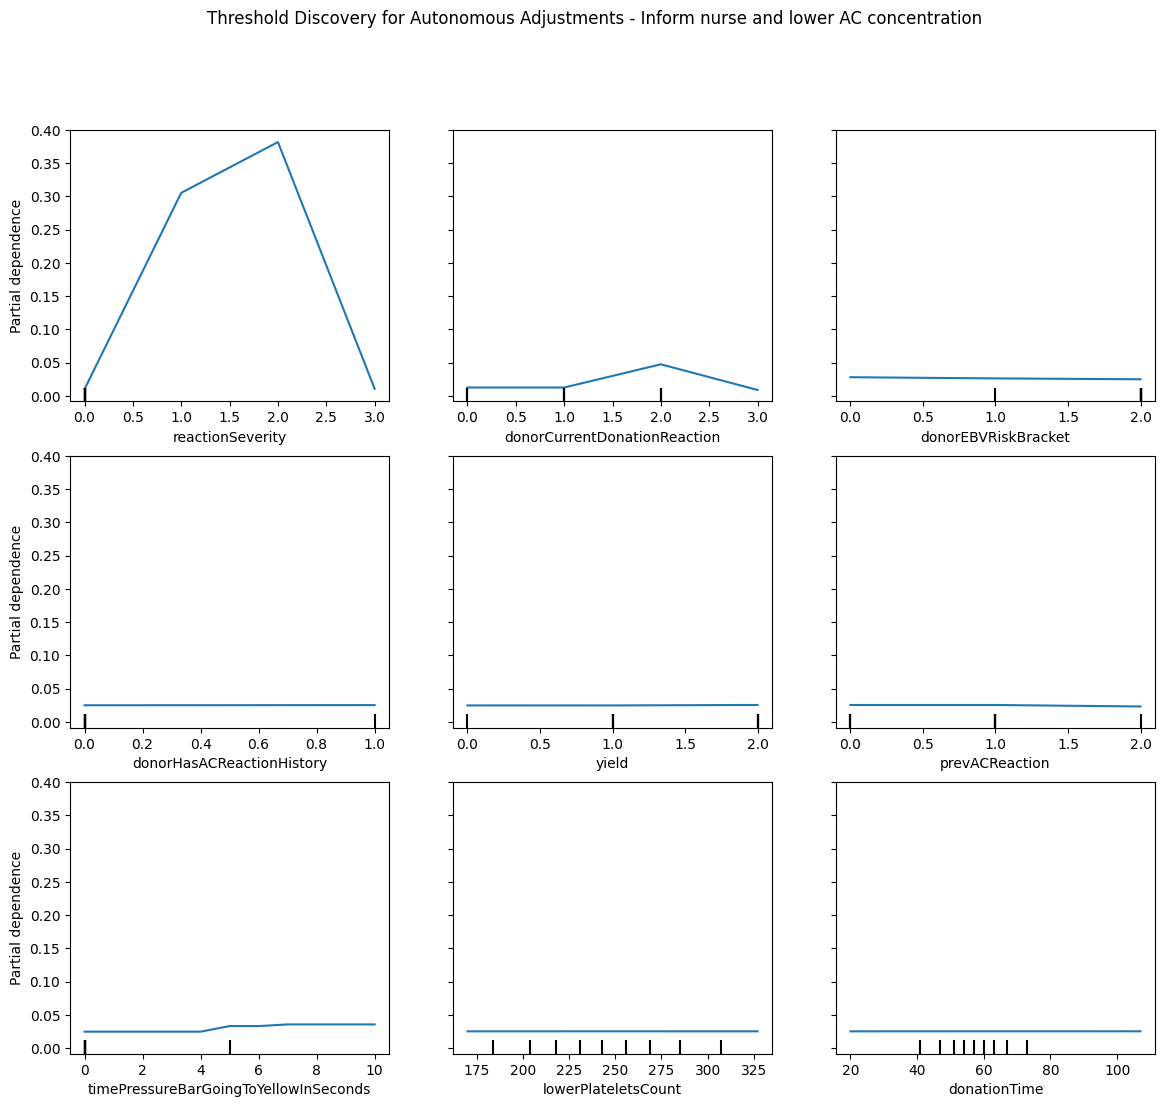

In [818]:
# Inform nurse and lower AC concentration
features_to_plot = [
    'reactionSeverity', 'donorCurrentDonationReaction', 'donorEBVRiskBracket',
    'donorHasACReactionHistory', 'yield', 'prevACReaction',
    'timePressureBarGoingToYellowInSeconds', 'lowerPlateletsCount', 'donationTime'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[1], 
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[1]}")
plt.show()

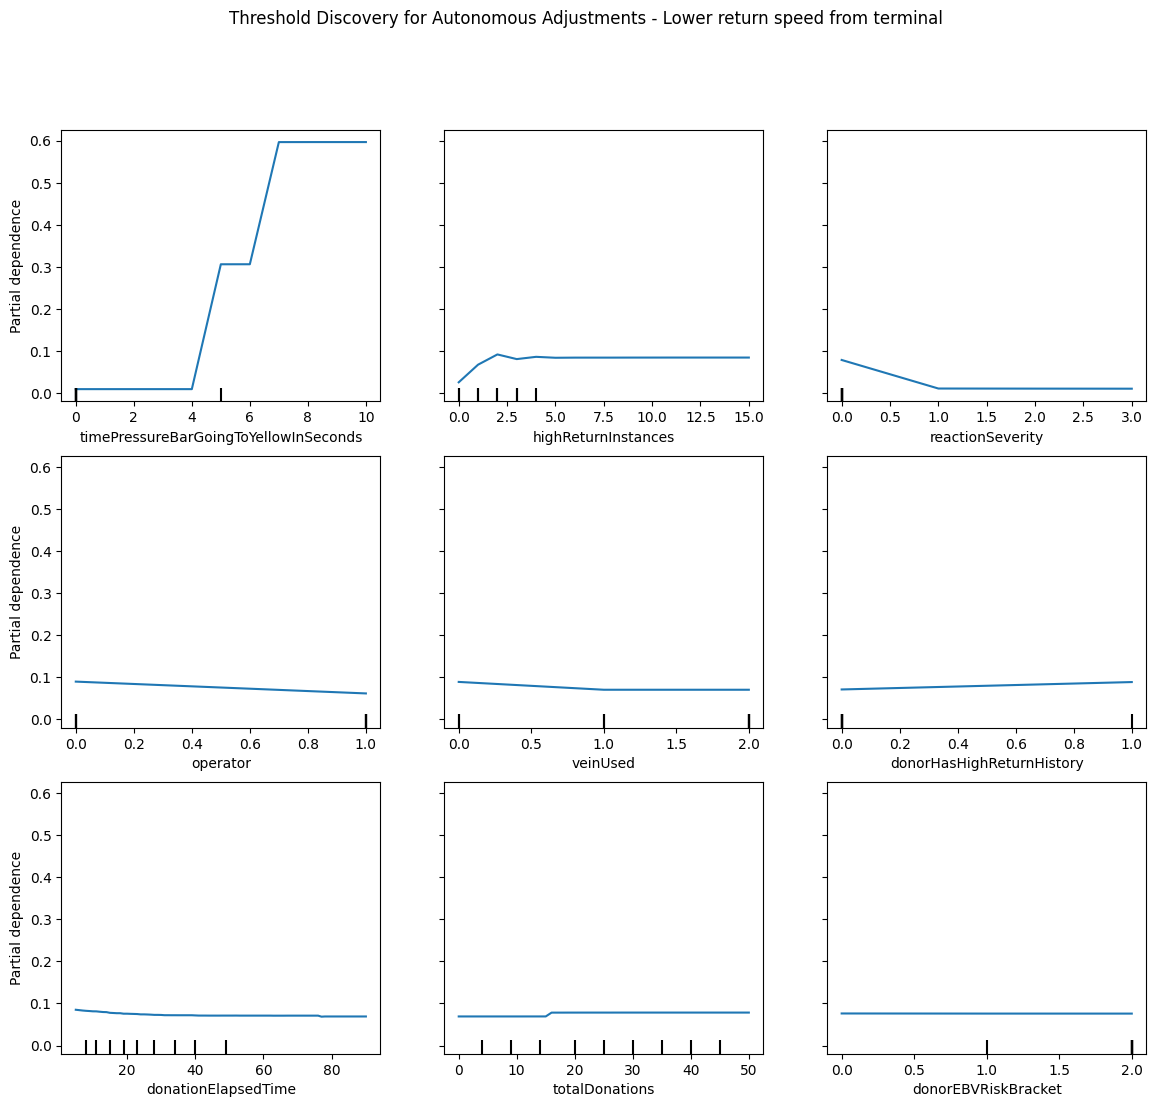

In [819]:
# Lower return speed from terminal
features_to_plot = [
    'timePressureBarGoingToYellowInSeconds', 'highReturnInstances', 'reactionSeverity',
    'operator', 'veinUsed', 'donorHasHighReturnHistory',
    'donationElapsedTime', 'totalDonations', 'donorEBVRiskBracket'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[2],
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[2]}")
plt.show()

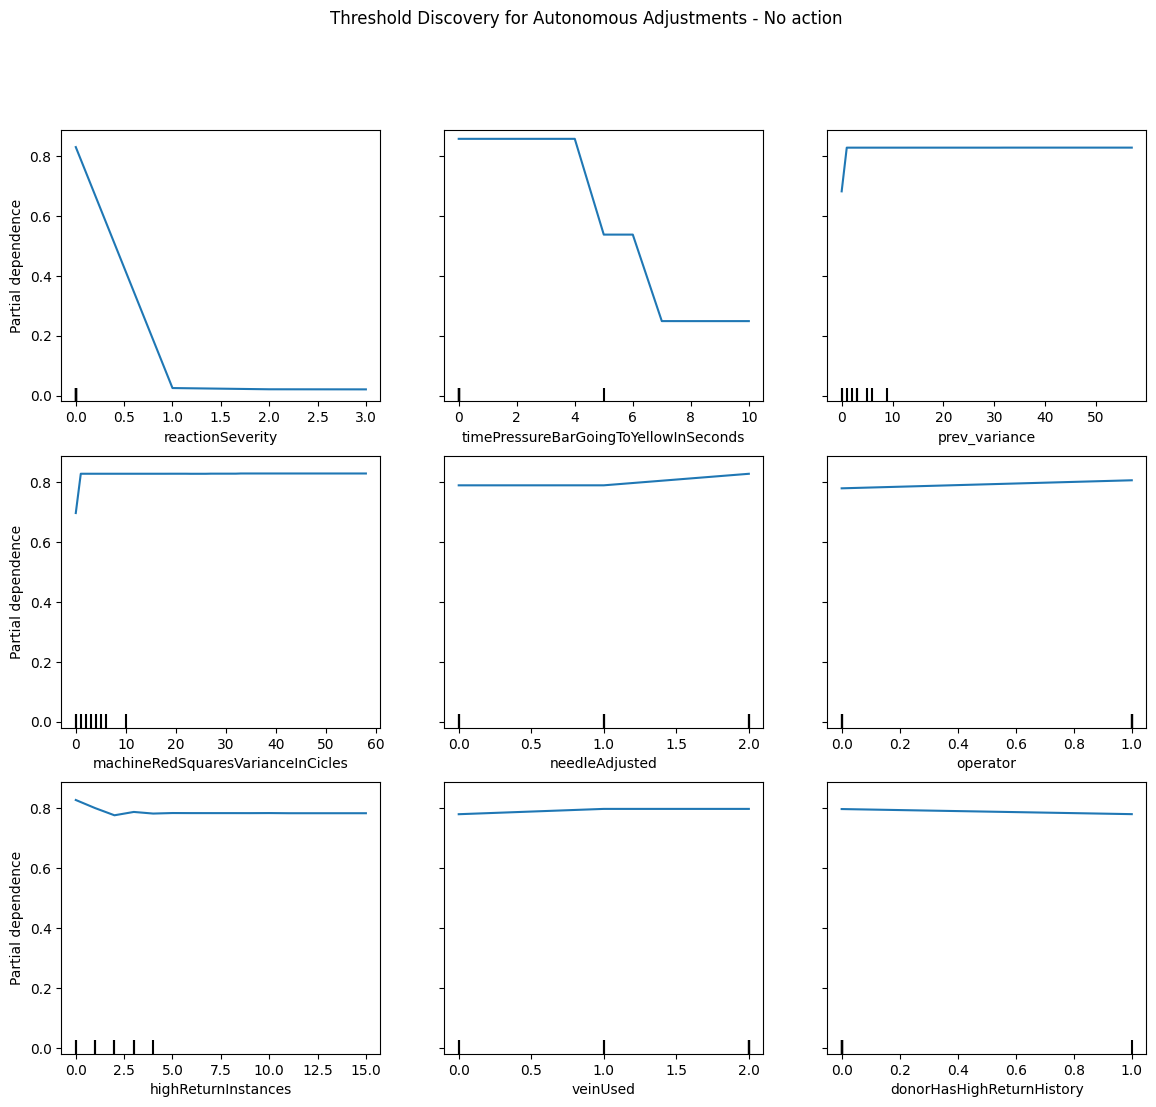

In [820]:
# No action
features_to_plot = [
    'reactionSeverity', 'timePressureBarGoingToYellowInSeconds', 'prev_variance',
    'machineRedSquaresVarianceInCicles', 'needleAdjusted', 'operator',
    'highReturnInstances', 'veinUsed', 'donorHasHighReturnHistory'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[3],
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[3]}")
plt.show()

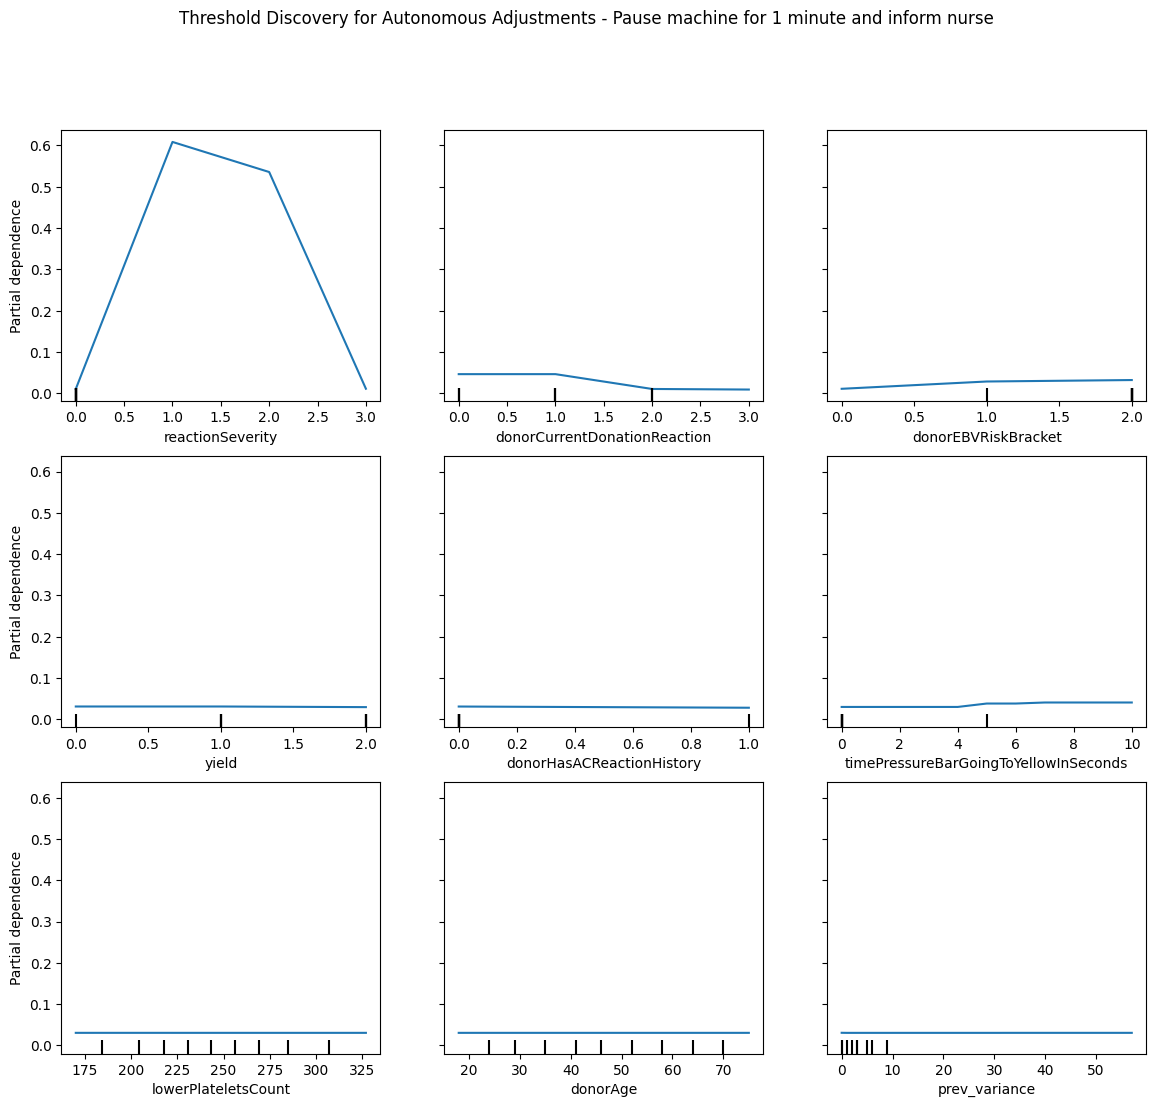

In [821]:
# Pause machine for 1 minute and inform nurse 
features_to_plot = [
    'reactionSeverity', 'donorCurrentDonationReaction', 'donorEBVRiskBracket',
    'yield', 'donorHasACReactionHistory', 'timePressureBarGoingToYellowInSeconds',
    'lowerPlateletsCount', 'donorAge', 'prev_variance'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[4],  
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[4]}")
plt.show()

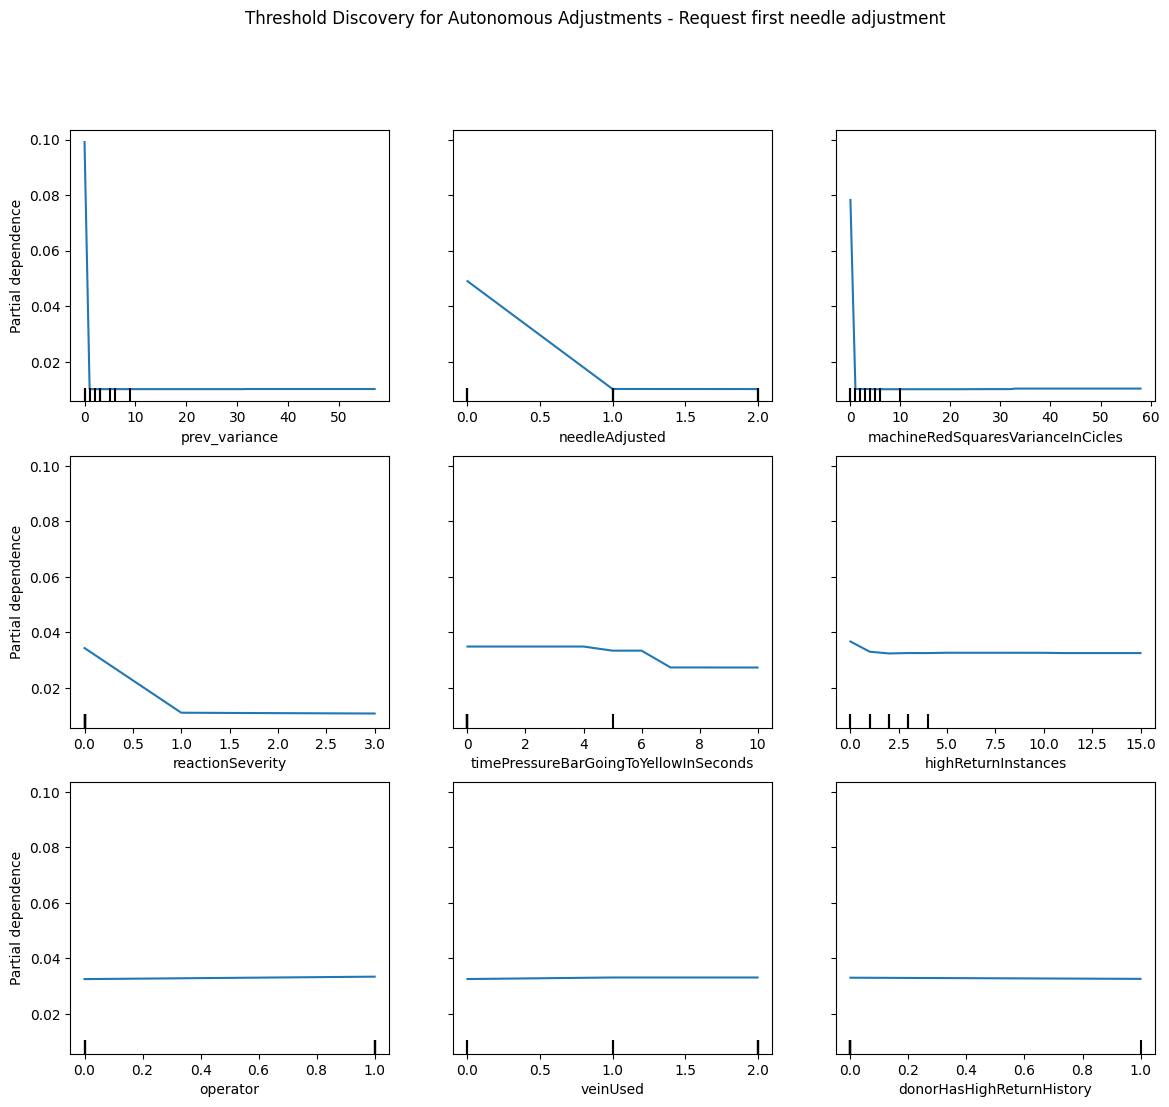

In [822]:
# Request first needle adjustment
features_to_plot = [
    'prev_variance', 'needleAdjusted', 'machineRedSquaresVarianceInCicles',
    'reactionSeverity', 'timePressureBarGoingToYellowInSeconds', 'highReturnInstances',
    'operator', 'veinUsed', 'donorHasHighReturnHistory'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[5],  
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[5]}")
plt.show()

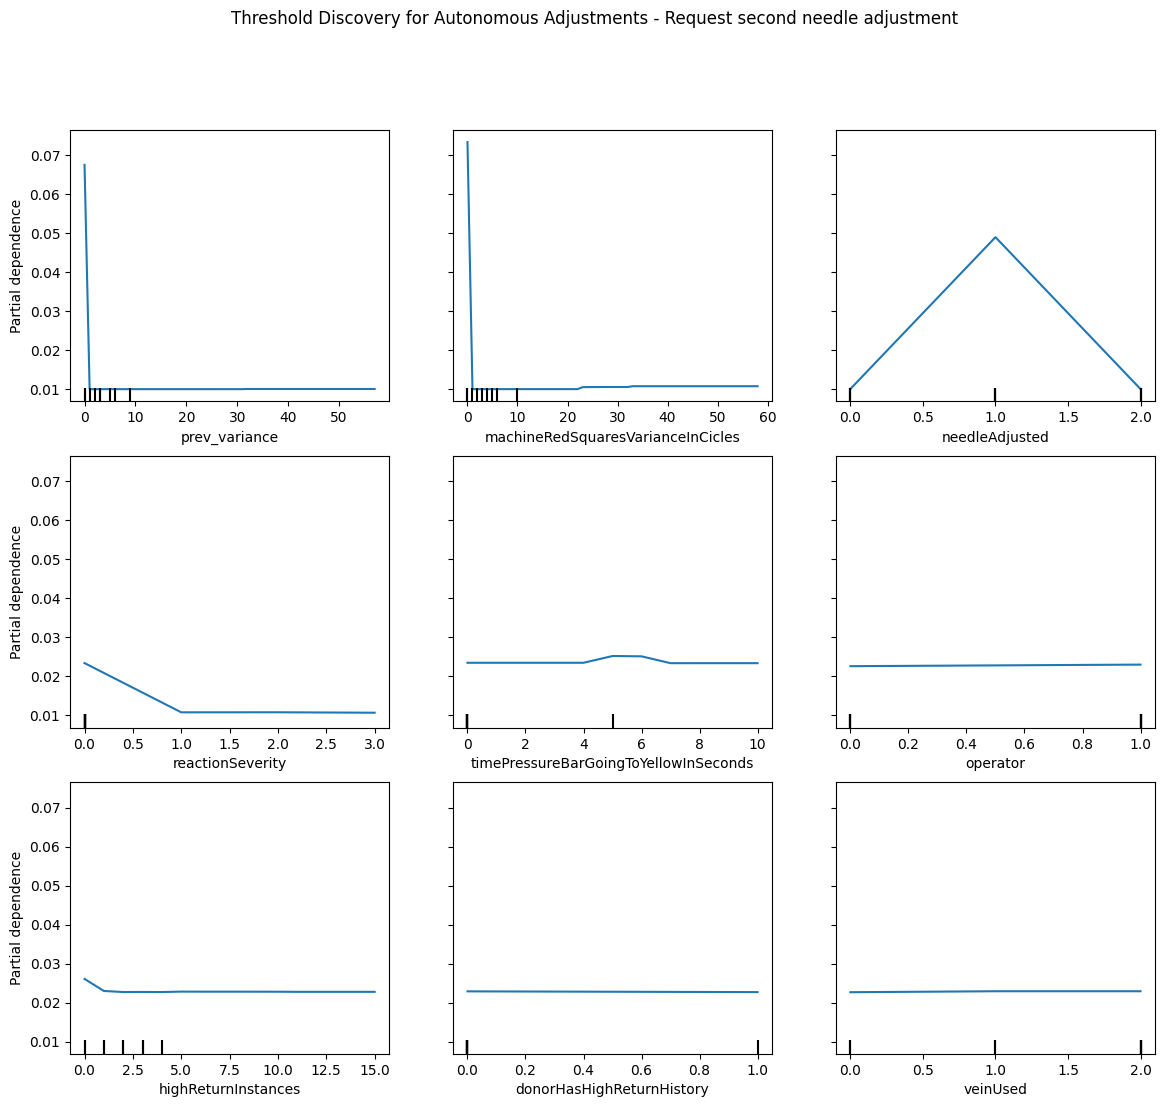

In [823]:
# Request second needle adjustment
features_to_plot = [
    'prev_variance', 'machineRedSquaresVarianceInCicles', 'needleAdjusted',
    'reactionSeverity', 'timePressureBarGoingToYellowInSeconds', 'operator',
    'highReturnInstances', 'donorHasHighReturnHistory', 'veinUsed'
]

fig, ax = plt.subplots(figsize=(14, (4 * (len(features_to_plot) // 3))))

PartialDependenceDisplay.from_estimator(
    pdp_model, 
    X_pdp, 
    features=features_to_plot,
    target=clss[6],  
    ax=ax
)

plt.suptitle(f"Threshold Discovery for Autonomous Adjustments - {clss[6]}")
plt.show()

## Simulation minute-by-minute SHAP scores and model outcome rationale

In [29]:
# XGB model simulation with SHAP feedback
def calculate_nadler_bv(sex: str, height_cm: float, weight_kg: float):
    h_m = height_cm / 100
    if sex == 'M':
        bv = (0.3669 * (h_m**3)) + (0.03219 * weight_kg) + 0.6041
    else:
        bv = (0.3561 * (h_m**3)) + (0.03308 * weight_kg) + 0.1833
    return bv


def predict_platelet_yield(sex: str, 
                            weight_kg: float, 
                            height_cm: float, 
                            hematocrit: float, 
                            platelet_count_k_per_ul: int):
    """
    Simulates a Terumo Trima Accel donation.
    Logic updated to enforce a 90-minute maximum and downgrade yields accordingly.
    """
    
    # Simulation Constants
    TARGET_YIELDS_E11 = [8.2, 7.8, 5.8, 5.4, 5.1, 3.0] # Triple -> Double -> Single
    
    CITRATE_INFUSION_LIMIT = 1.25
    AC_RATIO = 11.0           
    CITRATE_CONC_MG_ML = 15.4  
    COLLECTION_EFFICIENCY = 0.60
    
    # Time constraint
    MAX_DONATION_TIME_MIN = 90.0   
    MIN_POST_PLATELET_COUNT = 100000 

    # Calculate TBV using Nadler's Formula
    if sex.lower() in ['male', 'm']:
        tbv_ml = (0.3669 * (height_cm/100)**3) + (0.03219 * weight_kg) + 0.6041
    else:
        tbv_ml = (0.3561 * (height_cm/100)**3) + (0.03308 * weight_kg) + 0.1833
    tbv_ml *= 1000 

    # Calculate Citrate-Driven Flow Rates
    max_ac_rate_ml_min = (CITRATE_INFUSION_LIMIT * weight_kg) / CITRATE_CONC_MG_ML
    max_inlet_flow_ml_min = max_ac_rate_ml_min * AC_RATIO
    inlet_flow_ml_min = min(max_inlet_flow_ml_min, 100.0)

    # Determine Yield Potential (Biological/Safety Limits)
    platelet_count_per_ml = platelet_count_k_per_ul * 1000.0 * 1000.0
    # Rate of collection: Platelets per minute
    platelets_per_min = platelets_collected_per_ml_processed = (platelet_count_per_ml * COLLECTION_EFFICIENCY * inlet_flow_ml_min)
    
    # Constraint: Min Post-Count (Donor Safety)
    max_safe_take = (tbv_ml * platelet_count_per_ml) - (MIN_POST_PLATELET_COUNT * 1000 * tbv_ml)
    max_yield_post = max_safe_take / 1e11

    # Find Target and Enforce Time Limit
    selected_yield = 0
    predicted_time_min = 0
    status = "Donor deferred: Procedure exceeds 90 mins even for single dose."

    # Iterate through target yields from highest to lowest
    for target in TARGET_YIELDS_E11:
        # Calculate time required for THIS specific target
        time_required = (target * 1e11) / platelets_per_min
        
        # Check if donor has enough platelets AND it fits in 90 mins
        if (max_yield_post >= target) and (time_required <= MAX_DONATION_TIME_MIN):
            selected_yield = target
            predicted_time_min = time_required
            status = f"Target {target}e11 achieved within {round(predicted_time_min, 1)} mins."
            break
    else:
        # Fallback logic if no standard target is met within 90 mins
        # Calculate what they CAN give in exactly 90 mins
        max_yield_in_90 = (MAX_DONATION_TIME_MIN * platelets_per_min) / 1e11
        selected_yield = min(max_yield_in_90, max_yield_post)
        predicted_time_min = (selected_yield * 1e11) / platelets_per_min

    return [
        round(selected_yield, 2),
        round(predicted_time_min, 1),
        round(inlet_flow_ml_min, 2),
        round(tbv_ml, 0),
        status
    ]


def machine_setup():
    eligible = False
    while not eligible:
        # Apply the 93% Male donor skew
        sex = np.random.choice(['M', 'F'], p=[0.93, 0.07])
        
        # Generate Biometrics from UK mean/SD (2020-2025 data)
        if sex == 'M':
            height = np.random.normal(177, 7.1)
            weight = np.random.normal(85.1, 15.8)
            platelets = np.random.normal(235, 55)
            hematocrit = np.random.randint(40, 55)
        else:
            height = np.random.normal(164.6, 6.5)
            weight = np.random.normal(71.8, 16.2)
            platelets = np.random.normal(258, 62)
            hematocrit = np.random.randint(36, 49)
            
        # Validation Logic
        donor_bv = calculate_nadler_bv(sex, height, weight)
        
        # Check all three clinical constraints
        if (donor_bv >= 3.8) and (150 <= platelets <= 450):
            eligible = True

    # Final Donor Profile
    age = np.random.randint(18, 76)
    donations = np.random.randint(0, 51) if age > 20 else np.random.randint(0, 10)

    data = {
        'Donor age': int(age),
        'Donor sex': sex,
        'Height': round(height, 1),
        'Weight': round(weight, 1),
        'Hematocrits': round(hematocrit, 1),
        'Platelets count': int(platelets),
        'Donation number': donations,
        'Blood Volume (L)': round(donor_bv, 2)
    }

    inserted_data = list(data.values())

    # Calculate predicted yield
    predicted_donation_values = predict_platelet_yield(
        sex=data['Donor sex'], 
        weight_kg=data['Weight'],
        height_cm=data['Height'],
        hematocrit=data['Hematocrits'],
        platelet_count_k_per_ul=data['Platelets count']
    )

    return inserted_data, predicted_donation_values


def create_sim_donors_batch(batches: int, batch_size: int):
    df_collection = []
    for i in range(batches):
        dict_data = {
            'Donor ID': [],
            'Donor age': [],
            'Donor sex': [],
            'Height': [],
            'Weight': [],
            'Hematocrits': [],
            'Platelets count': [],
            'Donation number': [],
            'Blood Volume': [],
            'Yield': [],
            'Time': []
        }

        for id in range(batch_size):
            donor_data, donation_data = machine_setup()
            for idx, key in enumerate(dict_data):
                if idx == 0:
                    dict_data[key].append(id + (i*batch_size))
                else:
                    if idx < (len(donor_data)+1):
                        dict_data[key].append(donor_data[idx-1])
                    else:
                        dict_data[key].append(donation_data[idx-len(donor_data)-1])

        pd_donors_db = (pd.DataFrame.from_dict(dict_data))
        df_collection.append(pd_donors_db)
    print(f'Dataset of {(batches * batch_size) // 1000}K donors [batches: {batches}, size: {batch_size}] successfully created!')
    return df_collection


def xgb_inference(params: dict):  
    result = engine.predict(params)
    params['predLabel'] = result[0]
    return params


def prev_variance_updater(params: dict):
    params['prev_variance_1'] = params['prev_variance']
    params['prev_variance'] = params['machineRedSquaresVarianceInCicles']
    return params  


def get_sorted_shap_scores(model: xgb.core.Booster, X_dataframe: pd.DataFrame, engine):
    # Filter and identify prediction
    donor_row = X_dataframe.copy()

    if donor_row.empty:
        print('No data to calculate')
        return None
    predicted_label_str = donor_row['predLabel'].iloc[0]
    label_encoder = engine.target_encoder
    
    try:
        class_idx = list(label_encoder.classes_).index(predicted_label_str)
    except ValueError:
        return None
    
    # Pre-process features
    cols_to_drop = ['donorID', 'label', 'predLabel']
    features_only = donor_row.drop(columns=[c for c in cols_to_drop if c in donor_row.columns])
    
    df_encoded = features_only.copy()
    for col, encoder in engine.le_dict.items():
        if col in df_encoded.columns:
            val = str(df_encoded.iloc[0][col])
            try:
                df_encoded[col] = encoder.transform([val])[0]
            except:
                df_encoded[col] = 0
    
    df_encoded = df_encoded.astype('float32')

    # Generate SHAP values
    explainer = shap.Explainer(model)
    shap_values = explainer(df_encoded)

    # Extract scores for the predicted class
    # shap_values.values shape is (1, num_features, num_classes)
    raw_scores = shap_values.values[0, :, class_idx]
    formatted_scores = [float("{:.3f}".format(x)) for x in raw_scores]
    feature_names = df_encoded.columns.tolist()

    # Create dictionary and sort
    shap_dict = dict(zip(feature_names, formatted_scores))
    
    # Sort by absolute value (magnitude of impact)
    sorted_shap = dict(sorted(shap_dict.items(), key=lambda item: abs(item[1]), reverse=True))

    filtered_shap = {}
    for key in sorted_shap:
        val = sorted_shap[key]
        if val >= 0.05:
            filtered_shap[key] = val

    for key in filtered_shap:
        val = donor_row[key].iloc[0]
        if type(val) == np.str_ or type(val) == str:
            new_val = str(val)
        else:
            new_val = int(val)
        filtered_shap[key] = new_val

    filtered_shap['class'] = predicted_label_str
    print(filtered_shap)

    return filtered_shap


def shap_scores_preprocessing(scores: dict):
    features = {
        'donorAge': 'Donnor Age',                                                                            
        'reactionSeverity': 'Citrate reaction severity',                          
        'donorCurrentDonationReaction': 'Citrate reactions',                                 
        'timePressureBarGoingToYellowInSeconds': 'High return flow pressure in time (seconds)',                                  
        'instancesMachineWasStoppedByOperator': 'Times machine was stopped by the operator',                                  
        'instancesMachineStopped': 'Times machine stopped',  
        'lowerPlateletsCount': 'Platelet count',                                                  
        'donationElapsedTime': 'Donation elapsed time',                                              
        'donorSex': "Donor's sex",                                                       
        'needleAdjusted': 'Times needle was adjusted',                                                        
        'donorHasLowDrawHistory': "Donor's low draw history",                                           
        'donorHasHighReturnHistory': "Donor's high return history",                  
        'donorEBVRiskBracket': "Donor's EBV based risk bracket",                            
        'prev_variance': 'Previous cycle red quares variance count',
        'prev_variance_1': 'Previous 2 cycles red square variance count',
        'machineRedSquaresVarianceInCicles': 'Red square variance count',                                     
        'donationTime': 'Total donation time',
        'donorHasACReactionHistory': "Donor's citrate reaction history",
        'prevACReaction': 'Previous citrate reaction severity',
        'yield': 'Donation yield',      
        'operator': 'Operator',
        'veinUsed': 'Vein canalised',
        'highReturnInstances': 'Times return flow was high',
        'totalDonations': "Donor's total donations"
    }

    severity_scores = {
        '0': 'None',
        '1': 'Mild',
        '2': 'Moderate',
        '3': 'Severe'
    }

    donation_yield = {
        '0': 'Single dose',
        '1': 'Double dose',
        '2': 'Triple dose',
    }

    EBV_risk = {
        '0': 'High risk',
        '1': 'Medium risk',
        '2': 'Low risk',
    }

    formatted_scores = {}
    for key in scores:
        if key in features:
            if key == 'reactionSeverity':
                for sev_key in severity_scores:
                    if int(sev_key) == scores[key]:
                        val = severity_scores[sev_key]
                formatted_scores[features[key]] = val
            elif key == 'yield':
                for sev_key in donation_yield:
                    if int(sev_key) == scores[key]:
                        val = donation_yield[sev_key]
                formatted_scores[features[key]] = val
            elif key == 'donorEBVRiskBracket':
                for sev_key in EBV_risk:
                    if int(sev_key) == scores[key]:
                        val = EBV_risk[sev_key]
                formatted_scores[features[key]] = val
            else:
                formatted_scores[features[key]] = scores[key]
    formatted_scores['class'] = scores['class']

    shap_features = [f"{k}: {v}" for k, v in formatted_scores.items() if k != 'class']
    # return shap_features
    outcome = formatted_scores.get('class', 'Unknown')
    params = ''
    for var in shap_features:
        params += ('* ' + var + os.linesep)
    template = "Most relevant features for decision:" + os.linesep + os.linesep + params + os.linesep + f"Model outcome: {outcome.upper()}"

    return template


def plot_predicted_label_shap(model: xgb.core.Booster, X_dataframe: pd.DataFrame, minute: int, donor_id: int, engine):
    # Filter for the specific donor and minute
    donor_row = X_dataframe.copy()
    
    if donor_row.empty:
        print(f"No data found")
        return

    # Identify the Predicted Label and its Index
    predicted_label_str = donor_row['predLabel'].iloc[0]
    label_encoder = engine.target_encoder
    
    # Identify which index (0-6) corresponds to the prediction
    try:
        class_idx = list(label_encoder.classes_).index(predicted_label_str)
    except ValueError:
        print(f"Label '{predicted_label_str}' not found in encoder classes.")
        return

    # Pre-process features (Drop metadata and Encode strings)
    cols_to_drop = ['donorID', 'label', 'predLabel']
    features_only = donor_row.drop(columns=[c for c in cols_to_drop if c in donor_row.columns])
    
    df_encoded = features_only.copy()
    for col, encoder in engine.le_dict.items():
        if col in df_encoded.columns:
            val = str(df_encoded.iloc[0][col])
            try:
                df_encoded[col] = encoder.transform([val])[0]
            except:
                df_encoded[col] = 0 # Default fallback
    
    # Cast to float for XGBoost compatibility
    df_encoded = df_encoded.astype('float32')

    # Generate SHAP values
    explainer = shap.Explainer(model)
    shap_values = explainer(df_encoded)

    # XGBoost Prediction
    dmat = xgb.DMatrix(df_encoded)
    probs = model.predict(dmat)

    # Slice the explanation for the predicted class
    # shap_values shape is (1, num_features, num_classes)
    # We want (row 0, all features, specific class index)
    predicted_explanation = shap_values[0, :, class_idx]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Prediction: {predicted_label_str}\nDonor {donor_id} | Minute {minute} | Prob {(probs.max() * 100):.2f}%")
    shap.plots.waterfall(predicted_explanation, max_display=10)
    plt.show()


# Sets the donation parameters at the beginning of the donation based on the donor data, 
# and adds the necessary parameters for the simulation to run (e.g. EBV risk bracket, yield dose)
def parameters_starter(donor_data: pd.Series, params: dict):
    donation_yield = float(donor_data['Yield'])
    # Find yield dose
    if donation_yield < 5:
        params['yield'] = 0
    elif 5 < donation_yield < 7:
        params['yield'] = 1
    else:
        params['yield'] = 2
    # Find EBV risk bracket
    donor_EBV = float(donor_data['Blood Volume'])
    if 3.8 <= donor_EBV < 4.3:
        params['donorEBVRiskBracket'] = 0
    elif 4.3 <= donor_EBV < 4.8:
        params['donorEBVRiskBracket'] = 1
    else:
        params['donorEBVRiskBracket'] = 2
    params['donorID'] = int(donor_data['Donor ID'])
    params['donorAge'] = int(donor_data['Donor age'])
    params['totalDonations'] = int(donor_data['Donation number'])
    params['donorSex'] = donor_data['Donor sex']
    params['lowerPlateletsCount'] = int(donor_data['Platelets count'])
    params['donationTime'] = int(donor_data['Time'])
    if donor_data['Donation number'] <= 16:
        # Give a chance of having AC reaction history 
        params['donorHasACReactionHistory'] = np.random.choice(['yes', 'no'])
    if donor_data['Donation number'] < 16:
        # Give a chance of having high return history
        params['donorHasHighReturnHistory'] = np.random.choice(['yes', 'no'])
    return params


# Set the chance of the draw and return to be ubnormal depending on what adjustments have been made during the donation
def scenario_orchestrator(params: dict, bias: bool, 
                        AC_bias: bool, return_flow_reduced: int, 
                        AC_concentration_reduced: bool, machine_paused_for_AC: bool):
    # Initaiate output list with normal flow values
    output = ['normal_draw', 'normal_return', 'normal_AC']
    # Calculate chances
    # --- DRAW PHASE
    if bias:
        if params['needleAdjusted'] == 0:
            # 60% chance of being low draw when no needle adjustment is performed
            low_draw = True if np.random.randint(5) in [0, 1, 2] else False
        elif params['needleAdjusted'] == 1:
            # 40% chance of being low draw when needle adjustment is performed
            low_draw = True if np.random.randint(5) in [0, 1] else False
        else:
            # 25% chance of being low draw when 2 needle adjustments are performed
            low_draw = True if np.random.randint(4) == 0 else False
    else:
        if params['needleAdjusted'] == 0:
            # 33% chance of being low draw if no needle adjustment is performed
            low_draw = True if np.random.randint(3) == 0 else False
        elif params['needleAdjusted'] == 1:
            # 20% chance of being low draw when needle adjustment is performed
            low_draw = True if np.random.randint(5) == 0 else False
        else:
            # 10% chance of being low draw if needle adjustment is performed
            low_draw = True if np.random.randint(10) == 0 else False

    # --- RETURN PHASE
    # Determine baseline risk using the "reduce return speed" label rules
    total_donations = params['totalDonations']
    operator = params['operator']
    vein_used = params['veinUsed']
    history = params['donorHasHighReturnHistory']
    instances = params['highReturnInstances']

    is_high_risk = False
    
    # Flag high risk based on the label rules 
    if total_donations >= 70:
        is_high_risk = True
    elif 15 < total_donations < 70 and (operator == 'junior' and vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations < 16 and (history == 'yes' or operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations >= 70 and (operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True
    if is_high_risk:
        # 33% starting chance of being high return if risk factors are present (moderately mitigated)
        high_return = True if np.random.randint(3 + return_flow_reduced) == 0 else False
    else:
        # 16.6% starting chance of being high return (moderately mitigated)
        high_return = True if np.random.randint(6 + return_flow_reduced) == 0 else False

    # --- AC PHASE
    if AC_bias:
        # High risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if machine_paused_for_AC:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
            elif AC_concentration_reduced:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 60% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1, 2] else False
        # Medium risk donors chances
        elif params['donorEBVRiskBracket'] == 1:
            if machine_paused_for_AC:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            elif AC_concentration_reduced:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            else:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
        # Low risk donors chances
        elif params['donorEBVRiskBracket'] == 2:
            if machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
    else:
        # High risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
        # Medium and Low risk donors chances
        else:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 3% chance of being high AC
                high_AC = True if np.random.randint(33) == 0 else False
            elif AC_concentration_reduced:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif machine_paused_for_AC:
                # 16.6% chance of being high AC
                high_AC = True if np.random.randint(6) == 0 else False
            else:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
    # Assign output
    if low_draw:
        output[0] = 'low_draw'
    if high_return:
        output[1] = 'high_return'
    if high_AC:
        output[-1] = 'high_AC'
    return output


def low_draw_stop_logic(params: dict):
    # Only stop machine in case of 3 red squares in a row
    if params['prev_variance'] == 0 and params['prev_variance_1'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0:
        params['instancesMachineStopped'] += 1
        # Extend donation due to low draw speed
        params['donationTime'] += 10
        return params
    else: return params


def draw_speed_boost(params: dict, initial_donation_time: int):
    cycle_variance = params['machineRedSquaresVarianceInCicles']
    current_donation_time = params['donationTime']
    # Speed up donation ONLY if the last 5 cycles were good, and the donation time is currently longer than the original predictet time
    if cycle_variance > 4 and current_donation_time > initial_donation_time:
        if (current_donation_time - params['donationElapsedTime']) <= 11:
            pass
        else:
            params['donationTime'] -= 10
    return params


def prev_variance_updater(params: dict):
    params['prev_variance_1'] = params['prev_variance']
    params['prev_variance'] = params['machineRedSquaresVarianceInCicles']
    return params


def draw_flow(orchestrator_output: list, params: dict, original_time: int):
    # Check orchestrator output
    if 'low_draw' == orchestrator_output[0]:
        # Add probability of the machine stopping due to low draw, variance <= 2, machine paused >=3
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = 0
        params = low_draw_stop_logic(params)
    else:
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = int(params['machineRedSquaresVarianceInCicles']) + 1
        params = draw_speed_boost(params, original_time)
    return params


def return_flow(orchestrator_output: list, params: dict):
    end_donation = False
    # Check orchestrator output
    if 'high_return' in orchestrator_output:
        # 7% chance that the return bruises the donor
        if (np.random.randint(14) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
            end_donation = True
            return params, end_donation
        # 50% chance of being a slightly high return flow
        if (np.random.randint(2) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(3, 6)
        else:
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
    # If not high return, reset the seconds count
    else:
        params['timePressureBarGoingToYellowInSeconds'] = 0
    return params, end_donation


def AC_flow(orchestrator_output: list, params: dict):
    # Check for previous cycle reaction
    if params['reactionSeverity'] != 0:
        # Update previous reaction parameter
        params['prevACReaction'] = params['reactionSeverity']
    params['reactionSeverity'] = 0
    # Check orchestrator output
    if 'high_AC' in orchestrator_output:
        # 33% chance of AC reaction symptoms
        if (np.random.randint(3) == 0):
            params['reactionSeverity'] = int(np.random.choice([1, 2, 3], p=[0.7, 0.2, 0.1]))
            params['donorCurrentDonationReaction'] += 1
            params['instancesMachineWasStoppedByOperator'] += 1
    return params


def assign_label(params: dict, eval: str = 'off'):
    detected_priorities = []
    # --- PRIORITY 1: Stop Donation ---
    if (params['reactionSeverity'] == 3 or
        (params['donorCurrentDonationReaction'] == 3) or
        # 1st reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] > 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0)):
            detected_priorities.append((1, 'End donation, AC toxicity reached/buildup'))

    # --- PRIORITY 2: Reduce AC ---
        # 1st reaction
            # High EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 0) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] != 0 and params['reactionSeverity'] != 0)):
        detected_priorities.append((2, 'Inform nurse and lower AC concentration'))

    # --- PRIORITY 3: Pause Machine ---
        # 1st reaction
            # Medium EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] != 0)):
        detected_priorities.append((3, 'Pause machine for 1 minute and inform nurse'))

    # --- PRIORITY 4: Return Speed --- /// --- rules have been update to consider vein scarring
    if ((params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['operator'] == 'junior' and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['veinUsed'] == 'Basilic' and 15 < params['totalDonations'] < 70) or
        ## addition
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] >= 70) or # scarring from many donations
        ##
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['highReturnInstances'] % 2 == 0 and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['donorHasHighReturnHistory'] == 'yes') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['operator'] == 'junior') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['veinUsed'] == 'Basilic')):
        detected_priorities.append((4, 'Lower return speed from terminal'))

    # --- PRIORITY 5: Needle Adjustment 1 ---
    if eval == 'on':
        if (params['needleAdjusted'] == 0 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((5, 'Request first needle adjustment'))
    else:
        if (params['dummyNeedleAdjusted'] == 0 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((5, 'Request first needle adjustment'))

    # --- PRIORITY 6: Needle Adjustment 2 ---
    if eval == 'on':
        if (params['needleAdjusted'] == 1 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((6, 'Request second needle adjustment'))
    else:
        if (params['dummyNeedleAdjusted'] == 1 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((6, 'Request second needle adjustment'))

    # Final Decision: Sort by priority (lowest number first) and pick the top one
    if detected_priorities:
        detected_priorities.sort(key=lambda x: x[0])
        params['label'] = detected_priorities[0][1]
    else:
        params['label'] = 'No action'
    return params


def MMO_eval_running_sim(donor_data: pd.Series, outcomes: dict):
    # Initiate parameters
    params = {
        'donorID': 0,
        'donorAge': 0,                                                                                  
        'reactionSeverity': 0,                          
        'donorCurrentDonationReaction': 0,                                            
        'timePressureBarGoingToYellowInSeconds': 0,                                 
        'instancesMachineWasStoppedByOperator': 0,                                   
        'instancesMachineStopped': 0,  
        'lowerPlateletsCount': 0,                                                 
        'donationElapsedTime': 5,                                               
        'donorSex': '',                                                         
        'needleAdjusted': 0,                                                       
        'donorHasLowDrawHistory': 'no',                                             
        'donorHasHighReturnHistory': 'no',                 
        'donorEBVRiskBracket': 0,                          
        'prev_variance': 2,
        'prev_variance_1': 1,
        'machineRedSquaresVarianceInCicles': 3,                                    
        'donationTime': 0,
        'donorHasACReactionHistory': 'no',
        'prevACReaction': 0,
        'yield': 0,                                       
        'operator': '',
        'veinUsed': '',
        'highReturnInstances': 0,
        'totalDonations': 0,
        'label': 'No action',
        'predLabel': 'No action'
    }
    # Update parameters to current donor
    params = parameters_starter(donor_data, params)
    # Assign random operator type
    params['operator'] = np.random.choice(['junior', 'senior'])
    # Assign random vein used
    params['veinUsed'] = np.random.choice(['Cephalic', 'Basilic', 'Median'], p=[0.2, 0.3, 0.5])
    # Extract donation time from list
    donation_time = int(donor_data['Time'])
    # Draw bias, 50% chance of biased draw
    bias = True if (np.random.randint(2) == 0) else False
    # AC bias, 50% chance of biased AC for male donor
    AC_bias = True if (np.random.randint(2) == 0) else False
    # Return flow reduced flag
    reduced_return = 0
    # AC reduction flag
    reduced_AC = False
    # Machine pause due to AC reaction flag
    machine_paused_for_AC = False
    # Extract donor ID
    donor_ID = int(donor_data['Donor ID'])
    # Initiate donation outcome
    outcome = 'No issues'
    # Initiate donation status
    end_donation_status = False
    # Initial donation time
    initial_time = params['donationTime']
    # Loop through the minutes, and perform 1 return and 1 draw each minute
    for loop in range(donation_time - 5):
        scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
        params = AC_flow(scenario, params)
        params = draw_flow(scenario, params, initial_time)
        params, end_donation_status = return_flow(scenario, params)
        params = assign_label(params, eval='on')
        params = xgb_inference(params)
        # Check for return flow reduction
        if params['predLabel'] == 'Lower return speed from terminal':
            reduced_return += 1
            params['donationTime'] += 3
        # Check for AC concentration reduction
        if params['predLabel'] == 'Inform nurse and lower AC concentration':
            reduced_AC = True
        # Check for machine pause due to AC reaction
        if params['predLabel'] == 'Pause machine for 1 minute and inform nurse':
            machine_paused_for_AC = True
        # Check for donation early stop due to haematoma
        if end_donation_status:
            outcome = 'Donation stopped due to high return'
        # Check for donation early stop due to Ac reaction
        if 'End donation,' in params['label']:
            end_donation_status = True
            outcome = 'Donation stopped due to AC reaction/buildup'
        # Initiate dataframe to store each loop data
        if loop == 0:
            anchor = pd.DataFrame(params, index=[0])
            # SHAP
            shap_vals = get_sorted_shap_scores(engine.model, anchor, engine)
            template = shap_scores_preprocessing(shap_vals)
            # shap_feedback = generate_shap_feedback(llm, template)
            print(template)
            print()
            plot_predicted_label_shap(engine.model, anchor, params['donationElapsedTime'], params['donorID'], engine)
        else:
            # Generate a new pandas series to add to the main dataframe
            new_entry = pd.DataFrame(params, index=[0])
            #### SHAP
            shap_vals = get_sorted_shap_scores(engine.model, new_entry, engine)
            template = shap_scores_preprocessing(shap_vals)
            # shap_feedback = generate_shap_feedback(llm, template)
            print(template)
            print()
            plot_predicted_label_shap(engine.model, new_entry, params['donationElapsedTime'], params['donorID'], engine)
            # Add overwritten params to the dataframe
            anchor = pd.concat([anchor, new_entry], axis=0)
            # Stop donation if it slows down to be longer than 94 minutes
            if params['donationTime'] > 94:
                end_donation_status = True
                outcome = 'Donation stopped due to timeout'
        # Check for needle adjustments
        if params['predLabel'] == 'Request first needle adjustment' or \
        params['predLabel'] == 'Request second needle adjustment':
            params['needleAdjusted'] += 1
        if end_donation_status:
            break
        # Add to donation time tracker
        params['donationElapsedTime'] += 1
    # If donation stopped early, return simulation results
    if end_donation_status:
        pass
    # If donation completed normally, check for time extension
    else:
        # Check for time dilation due to low draw
        new_donation_time = params['donationTime']
        # Set up stack for while loop
        extended_time_history = [new_donation_time]
        force_stop_donation = False
        original_time_history = [donation_time]
        if donation_time != new_donation_time:
            while original_time_history[-1] != extended_time_history[-1]:
                # Keep looping through the minutes, and perform 1 return and 1 draw each minute
                for loop in range(new_donation_time - donation_time):
                    # Ensure donation does not keep going after time update (speed boost)
                    if params['donationElapsedTime'] == params['donationTime']:
                        # Break for and while loop
                        force_stop_donation = True
                        break
                    scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
                    params = AC_flow(scenario, params)
                    params = draw_flow(scenario, params, initial_time)
                    params, end_donation_status = return_flow(scenario, params)
                    params = assign_label(params, eval='on')
                    params = xgb_inference(params)
                    # Check for return flow reduction
                    if params['predLabel'] == 'Lower return speed from terminal':
                        reduced_return += 1
                        params['donationTime'] += 3
                    # Check for AC concentration reduction
                    if params['predLabel'] == 'Inform nurse and lower AC concentration':
                        reduced_AC = True
                    # Check for machine pause due to AC reaction
                    if params['predLabel'] == 'Pause machine for 1 minute and inform nurse':
                        machine_paused_for_AC = True
                    if end_donation_status:
                        outcome = 'Donation stopped due to high return'
                    if 'End donation,' in params['label']:
                        end_donation_status = True
                        outcome = 'Donation stopped due to AC reaction/buildup'
                    # Generate a new pandas series to add to the main dataframe
                    new_entry = pd.DataFrame(params, index=[0])
                    #### SHAP
                    shap_vals = get_sorted_shap_scores(engine.model, new_entry, engine)
                    template = shap_scores_preprocessing(shap_vals)
                    # shap_feedback = generate_shap_feedback(llm, template)
                    print(template)
                    print()
                    plot_predicted_label_shap(engine.model, new_entry, params['donationElapsedTime'], params['donorID'], engine)
                    # Add overwritten params to the dataframe
                    anchor = pd.concat([anchor, new_entry], axis=0)
                    # Stop donation if it slows down to be longer than 94 minutes
                    if params['donationTime'] > 94:
                        end_donation_status = True
                        outcome = 'Donation stopped due to timeout'
                    # Check for needle adjustments
                    if params['predLabel'] == 'Request first needle adjustment' or \
                    params['predLabel'] == 'Request second needle adjustment':
                        params['needleAdjusted'] += 1
                    # End donation early
                    if end_donation_status:
                        force_stop_donation = True
                        break
                    params['donationElapsedTime'] += 1
                if force_stop_donation:
                    break
                original_time_history.append(extended_time_history[-1])
                extended_time_history.append(params['donationTime'])
    outcomes['donor_ID'].append(donor_ID)
    outcomes['AC_bias'].append(AC_bias)
    outcomes['Draw_bias'].append(bias)
    outcomes['Num_return_reduced'].append(reduced_return)
    outcomes['outcome'].append(outcome)
    return anchor, outcomes


def eval_sim_engine(dataset_path: str = None, dataset: pd.DataFrame = None):
    # Read the source data
    if not dataset_path:
        entire_data = dataset
    else:
        entire_data = pd.read_csv(dataset_path)
    # Donation outcomes
    outcomes = {
        'donor_ID': [],
        'AC_bias': [],
        'Draw_bias': [],
        'Num_return_reduced': [],
        'outcome': []
    }
    # Loop through the dataset rows
    if len(entire_data.shape) == 1:
        seed_df, outcomes = MMO_eval_running_sim(entire_data, outcomes)
    else:
        for idx in tqdm(range(len(entire_data))):
            if idx == 0:
                seed_df, outcomes = MMO_eval_running_sim(entire_data.loc[idx], outcomes)
            else:
                latest_entry, outcomes = MMO_eval_running_sim(entire_data.loc[idx], outcomes)
                seed_df = pd.concat([seed_df, latest_entry], axis=0)
    pd_outcomes = pd.DataFrame(outcomes)
    return seed_df, pd_outcomes


In [22]:
batch = create_sim_donors_batch(20, 5000)
batch[0].head()

Dataset of 100K donors [batches: 20, size: 5000] successfully created!


,Donor ID,Donor age,Donor sex,Height,Weight,Hematocrits,Platelets count,Donation number,Blood Volume,Yield,Time
0,0,52,M,189.7,79.9,51,173,47,5.68,3.0,40.5
1,1,69,M,172.1,100.4,43,205,24,5.71,5.8,52.6
2,2,50,M,177.9,82.7,45,301,42,5.33,8.2,61.5
3,3,46,M,182.8,128.7,47,229,19,6.99,8.2,59.7
4,4,53,M,172.6,97.8,48,271,2,5.64,8.2,57.8


{'reactionSeverity': 1, 'donorCurrentDonationReaction': 1, 'class': 'Pause machine for 1 minute and inform nurse'}
Most relevant features for decision:

* Citrate reaction severity: Mild
* Citrate reactions: 1

Model outcome: PAUSE MACHINE FOR 1 MINUTE AND INFORM NURSE



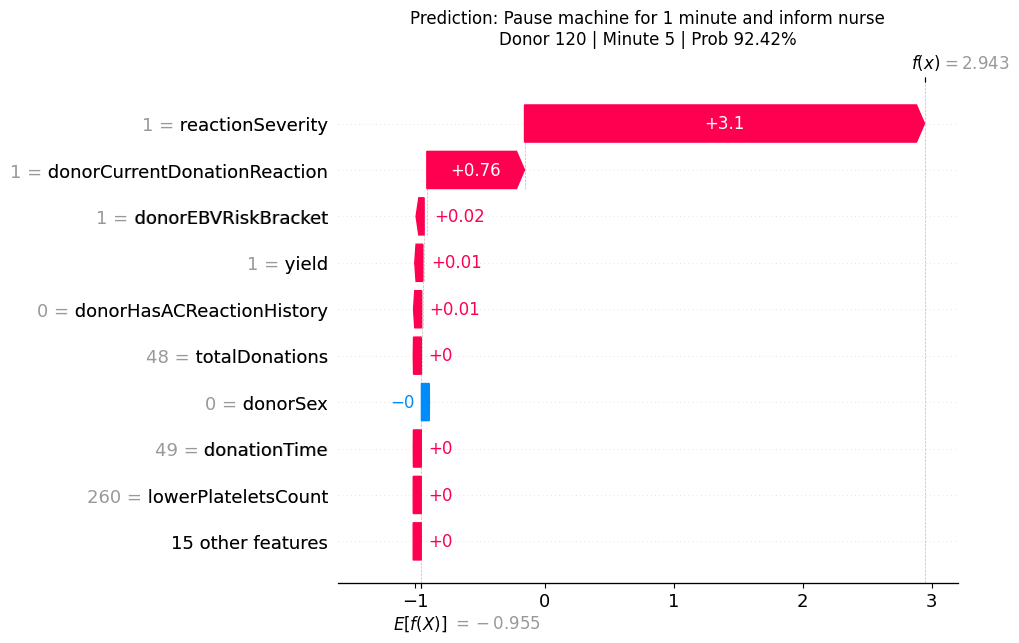

{'reactionSeverity': 0, 'timePressureBarGoingToYellowInSeconds': 0, 'prev_variance': 4, 'machineRedSquaresVarianceInCicles': 5, 'class': 'No action'}
Most relevant features for decision:

* Citrate reaction severity: None
* High return flow pressure in time (seconds): 0
* Previous cycle red quares variance count: 4
* Red square variance count: 5

Model outcome: NO ACTION



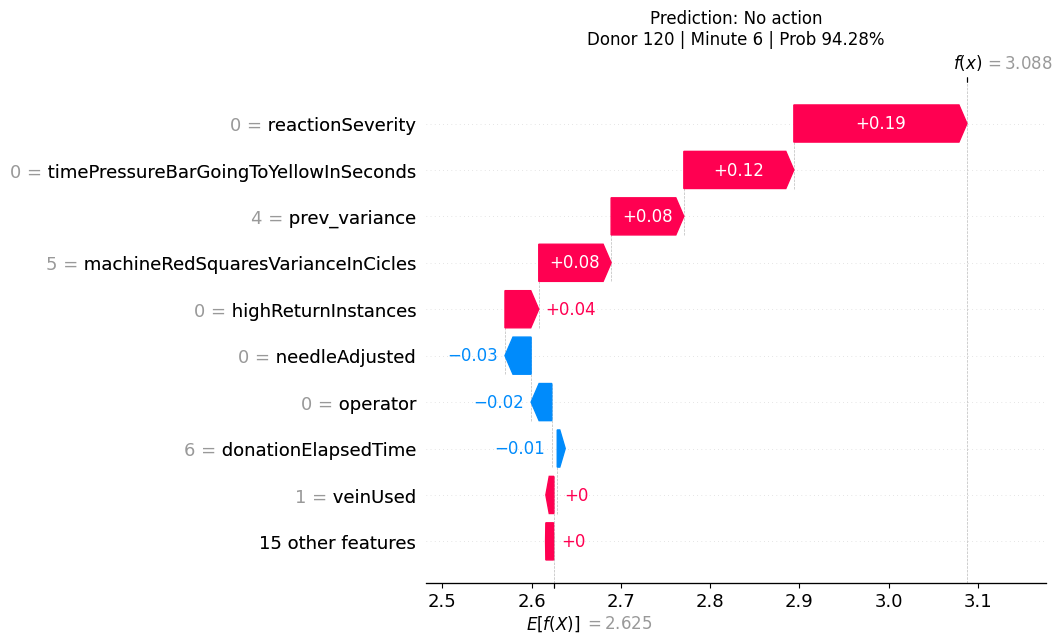

{'reactionSeverity': 0, 'timePressureBarGoingToYellowInSeconds': 0, 'prev_variance': 5, 'machineRedSquaresVarianceInCicles': 6, 'class': 'No action'}
Most relevant features for decision:

* Citrate reaction severity: None
* High return flow pressure in time (seconds): 0
* Previous cycle red quares variance count: 5
* Red square variance count: 6

Model outcome: NO ACTION



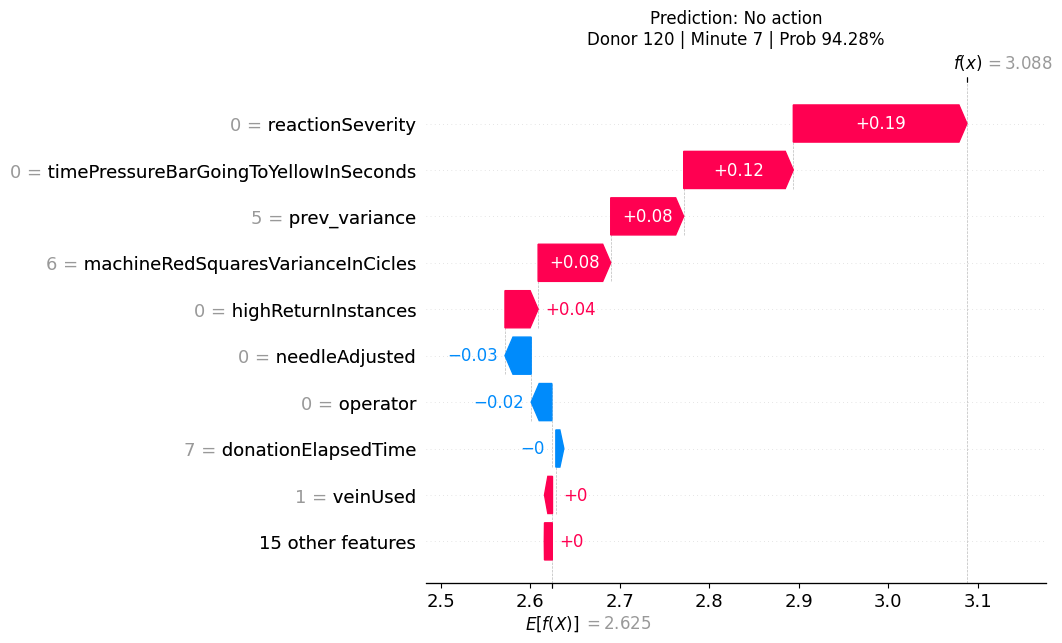

{'reactionSeverity': 0, 'timePressureBarGoingToYellowInSeconds': 0, 'prev_variance': 6, 'machineRedSquaresVarianceInCicles': 7, 'class': 'No action'}
Most relevant features for decision:

* Citrate reaction severity: None
* High return flow pressure in time (seconds): 0
* Previous cycle red quares variance count: 6
* Red square variance count: 7

Model outcome: NO ACTION



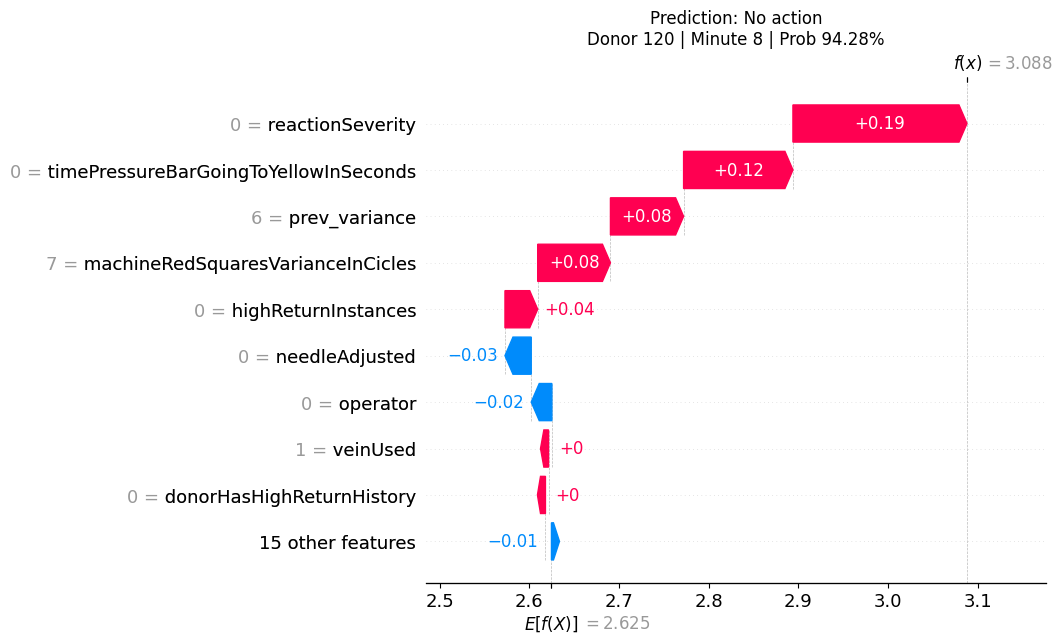

{'reactionSeverity': 0, 'timePressureBarGoingToYellowInSeconds': 0, 'prev_variance': 7, 'machineRedSquaresVarianceInCicles': 8, 'class': 'No action'}
Most relevant features for decision:

* Citrate reaction severity: None
* High return flow pressure in time (seconds): 0
* Previous cycle red quares variance count: 7
* Red square variance count: 8

Model outcome: NO ACTION



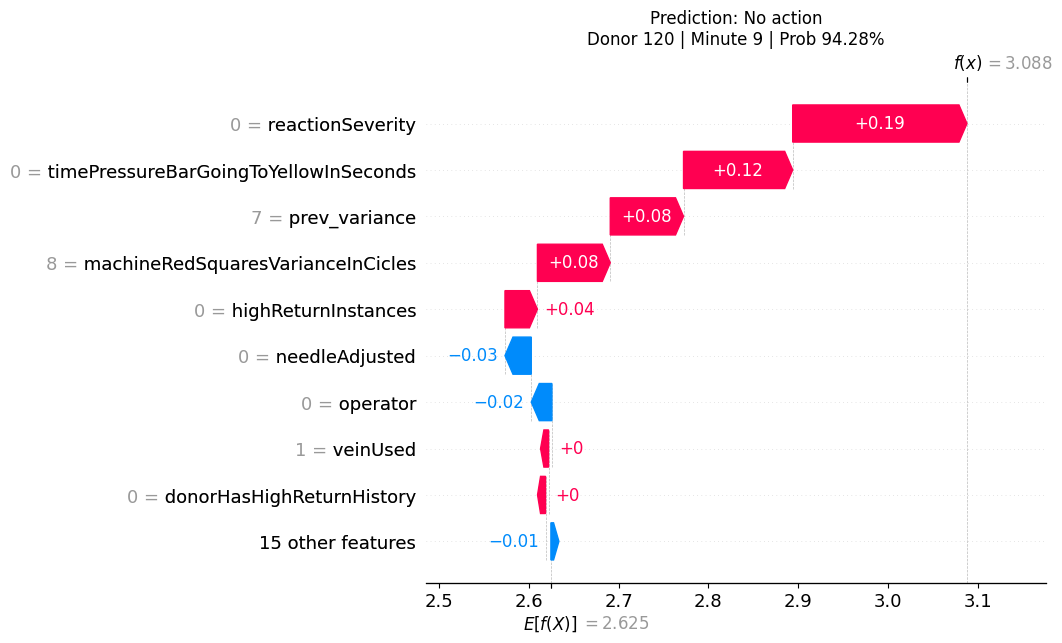

{'reactionSeverity': 0, 'timePressureBarGoingToYellowInSeconds': 0, 'prev_variance': 8, 'machineRedSquaresVarianceInCicles': 9, 'class': 'No action'}
Most relevant features for decision:

* Citrate reaction severity: None
* High return flow pressure in time (seconds): 0
* Previous cycle red quares variance count: 8
* Red square variance count: 9

Model outcome: NO ACTION



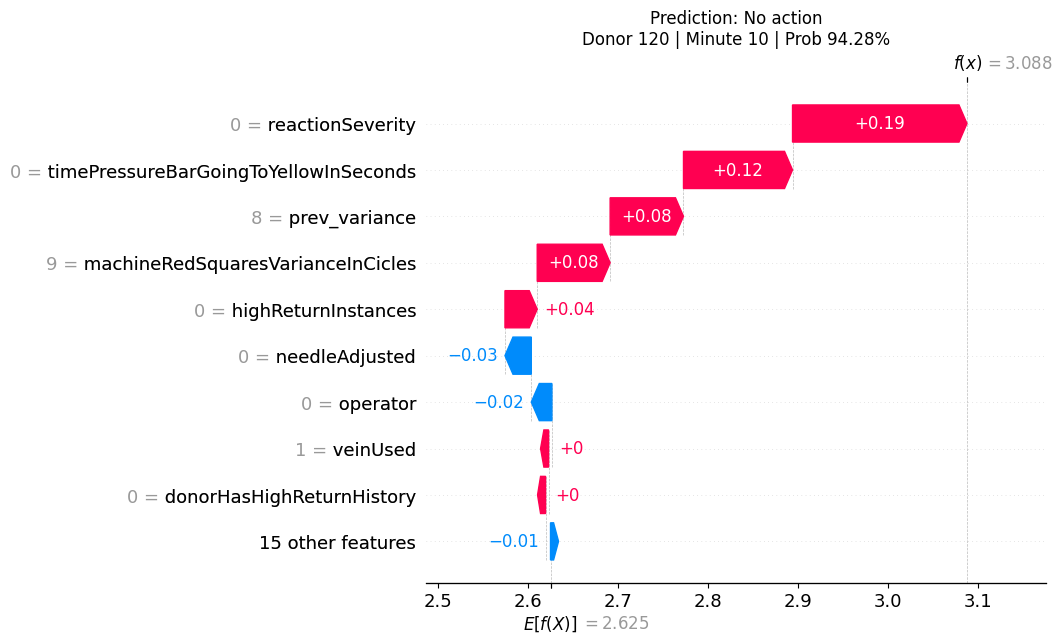

{'timePressureBarGoingToYellowInSeconds': 7, 'operator': 'junior', 'reactionSeverity': 0, 'class': 'Lower return speed from terminal'}
Most relevant features for decision:

* High return flow pressure in time (seconds): 7
* Operator: junior
* Citrate reaction severity: None

Model outcome: LOWER RETURN SPEED FROM TERMINAL



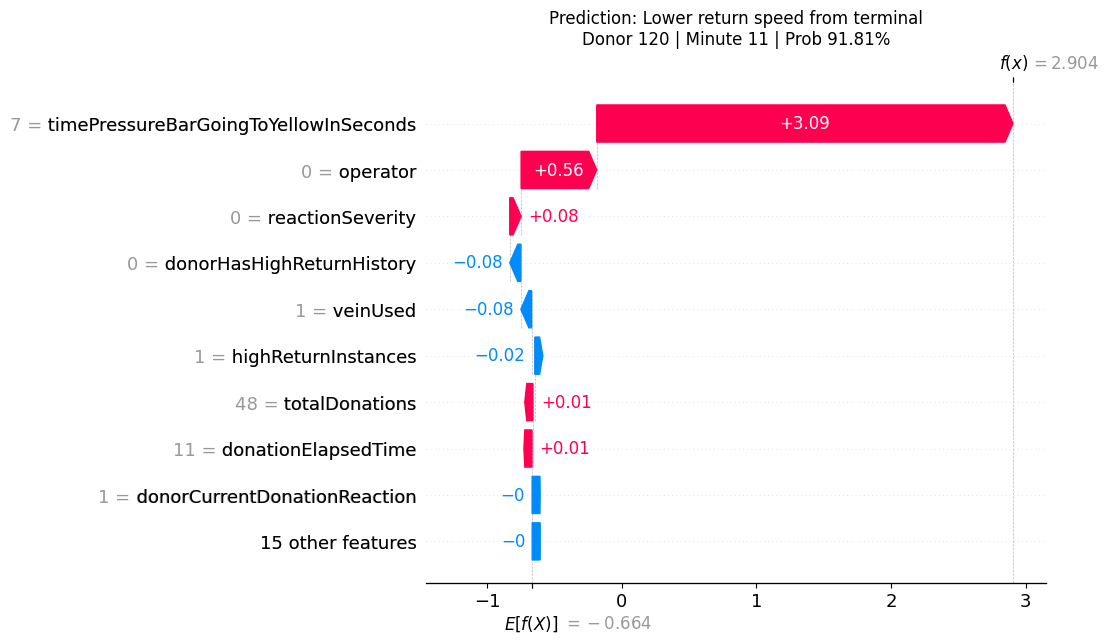

{'reactionSeverity': 3, 'class': 'End donation, AC toxicity reached/buildup'}
Most relevant features for decision:

* Citrate reaction severity: Severe

Model outcome: END DONATION, AC TOXICITY REACHED/BUILDUP



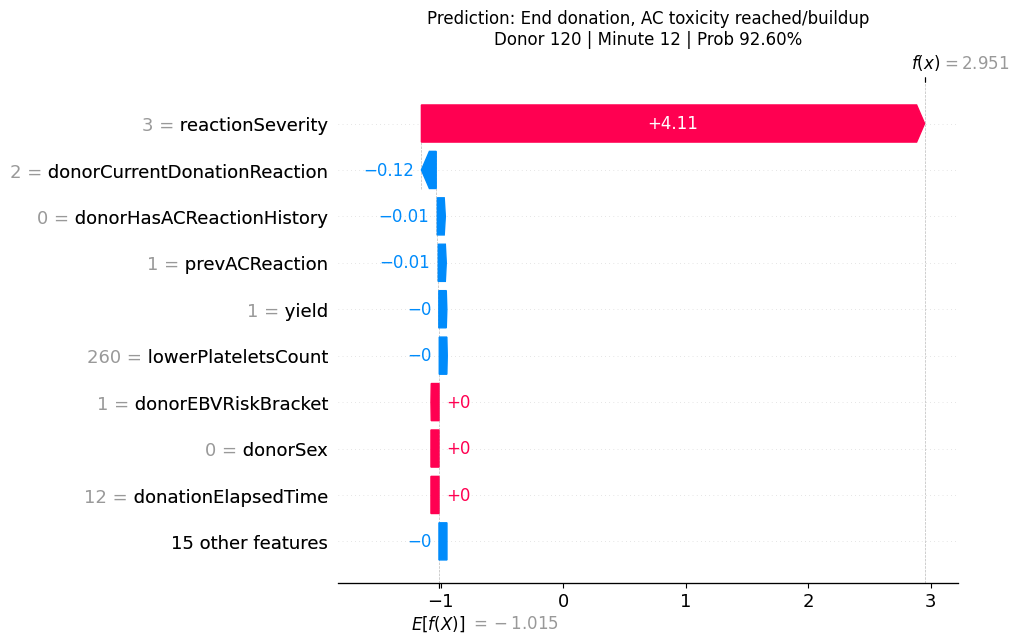

In [62]:
df, output = eval_sim_engine(dataset=batch[0].iloc[120])